🌀 ANALISI VARIETÀ DATASET FRATTALI
✅ Dataset quality caricato
🔍 ANALISI VARIETÀ DATASET
📊 STATISTICHE BASE:
   Dimensione dataset: (19138, 64, 64, 3)
   Range valori: [0.000, 1.000]
   Media: 0.215 ± 0.312
   Varianza media per immagine: 0.09279
   Range varianze: [0.02096, 0.15907]

🎨 ANALISI COLORI:
   Media RGB: R0.302 G0.208 B0.133
   Std RGB:   R0.377 G0.308 B0.200

🏗️  ANALISI STRUTTURA:
   Forza bordi media: 0.39771
   Complessità strutturale: 0.08222

👁️  CAMPIONI RAPPRESENTATIVI:


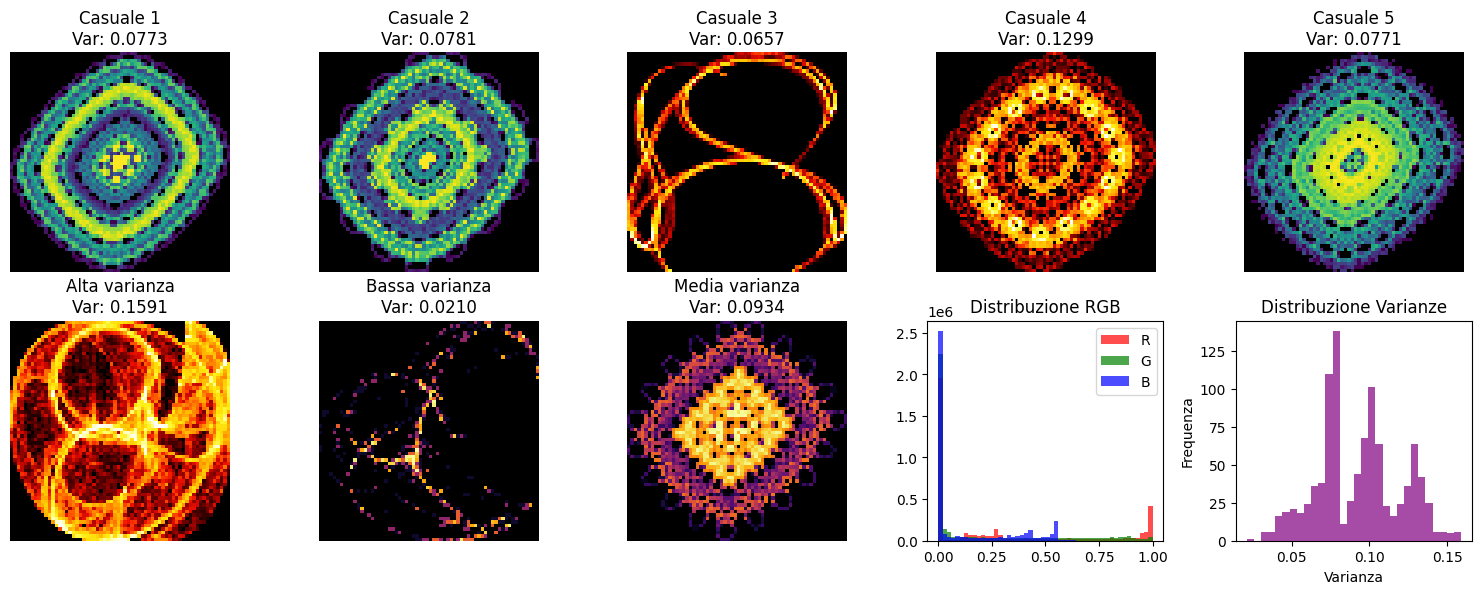


🔄 ANALISI SIMILARITÀ:
   Varianza spiegata PC1: 0.129
   Varianza spiegata PC2: 0.088
   Varianza totale spiegata: 0.217


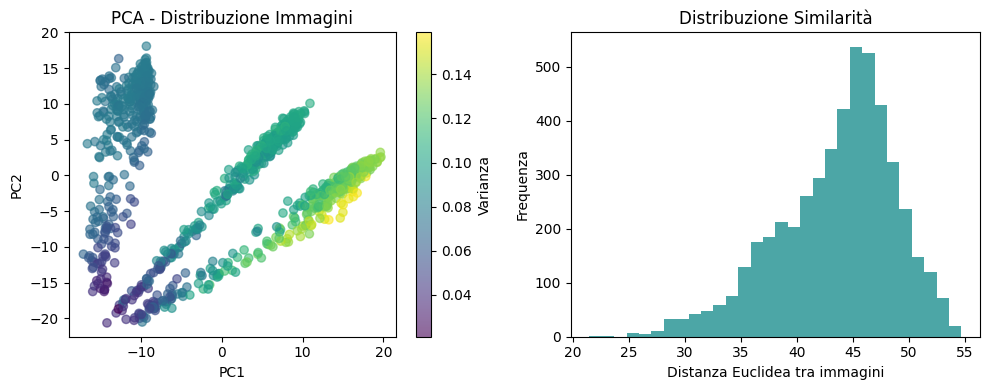


📈 VALUTAZIONE FINALE VARIETÀ:
   Varietà colore: 0.2950
   Varietà struttura: 0.0822
   Diversità complessiva: 0.000708
   SCORE VARIETÀ: 0.1281
   GIUDIZIO: 🎉 ECCELLENTE - Molto vario!

🎯 CONSIGLI PER MIGLIORARE LA VARIETÀ:

✅ DATASET GIÀ MOLTO VARIO!
   - Le reti generative avranno molto da imparare
   - Pattern complessi e diversificati
   - Ottimo per VAE/CAE/GAN!
    


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import seaborn as sns

def analyze_dataset_variety(dataset, sample_size=1000):
    """
    Analizza la varietà e diversità del dataset frattale
    """
    print("🔍 ANALISI VARIETÀ DATASET")
    print("=" * 50)
    
    # Campiona un subset per analisi più veloce
    if len(dataset) > sample_size:
        indices = np.random.choice(len(dataset), sample_size, replace=False)
        sample_data = dataset[indices]
    else:
        sample_data = dataset
    
    # 1. ANALISI STATISTICHE BASE
    print("📊 STATISTICHE BASE:")
    print(f"   Dimensione dataset: {dataset.shape}")
    print(f"   Range valori: [{dataset.min():.3f}, {dataset.max():.3f}]")
    print(f"   Media: {dataset.mean():.3f} ± {dataset.std():.3f}")
    
    # Calcola varianza tra immagini
    variances = []
    for img in sample_data:
        variances.append(np.var(img))
    
    print(f"   Varianza media per immagine: {np.mean(variances):.5f}")
    print(f"   Range varianze: [{np.min(variances):.5f}, {np.max(variances):.5f}]")
    
    # 2. ANALISI DISTRIBUZIONE DEI COLORI
    print("\n🎨 ANALISI COLORI:")
    
    # Distribuzione dei valori RGB
    flat_pixels = sample_data.reshape(-1, 3)
    rgb_means = np.mean(flat_pixels, axis=0)
    rgb_stds = np.std(flat_pixels, axis=0)
    
    print(f"   Media RGB: R{rgb_means[0]:.3f} G{rgb_means[1]:.3f} B{rgb_means[2]:.3f}")
    print(f"   Std RGB:   R{rgb_stds[0]:.3f} G{rgb_stds[1]:.3f} B{rgb_stds[2]:.3f}")
    
    # 3. ANALISI STRUTTURALE (Edge detection)
    print("\n🏗️  ANALISI STRUTTURA:")
    from scipy import ndimage
    
    edge_strengths = []
    for img in sample_data[:100]:  # Solo 100 per performance
        # Converti in scala di grigi
        gray = np.mean(img, axis=2)
        # Calcola bordi (gradienti)
        edges = ndimage.sobel(gray)
        edge_strength = np.mean(np.abs(edges))
        edge_strengths.append(edge_strength)
    
    print(f"   Forza bordi media: {np.mean(edge_strengths):.5f}")
    print(f"   Complessità strutturale: {np.std(edge_strengths):.5f}")
    
    # 4. VISUALIZZAZIONE CAMPIONI RAPPRESENTATIVI
    print("\n👁️  CAMPIONI RAPPRESENTATIVI:")
    
    # Trova immagini con varianza diversa
    high_var_idx = np.argmax(variances)
    low_var_idx = np.argmin(variances)
    mid_var_idx = np.argsort(variances)[len(variances)//2]
    
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    
    # Prime 5 immagini casuali
    random_indices = np.random.choice(len(sample_data), 5, replace=False)
    for i, idx in enumerate(random_indices):
        ax = axes[0, i]
        ax.imshow(sample_data[idx])
        ax.set_title(f'Casuale {i+1}\nVar: {variances[idx]:.4f}')
        ax.axis('off')
    
    # Immagini rappresentative
    reps = [high_var_idx, low_var_idx, mid_var_idx]
    rep_names = ['Alta varianza', 'Bassa varianza', 'Media varianza']
    
    for i, (idx, name) in enumerate(zip(reps, rep_names)):
        ax = axes[1, i]
        ax.imshow(sample_data[idx])
        ax.set_title(f'{name}\nVar: {variances[idx]:.4f}')
        ax.axis('off')
    
    # Ultimi 2: distribuzione colori
    ax = axes[1, 3]
    ax.hist(flat_pixels[:, 0], bins=50, alpha=0.7, color='red', label='R')
    ax.hist(flat_pixels[:, 1], bins=50, alpha=0.7, color='green', label='G')
    ax.hist(flat_pixels[:, 2], bins=50, alpha=0.7, color='blue', label='B')
    ax.set_title('Distribuzione RGB')
    ax.legend()
    
    ax = axes[1, 4]
    ax.hist(variances, bins=30, alpha=0.7, color='purple')
    ax.set_title('Distribuzione Varianze')
    ax.set_xlabel('Varianza')
    ax.set_ylabel('Frequenza')
    
    plt.tight_layout()
    plt.show()
    
    # 5. ANALISI SIMILARITÀ (PCA/TSNE semplificato)
    print("\n🔄 ANALISI SIMILARITÀ:")
    
    # Appiattisci le immagini
    flattened = sample_data.reshape(sample_data.shape[0], -1)
    
    # PCA per vedere variabilità principale
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(flattened)
    
    print(f"   Varianza spiegata PC1: {pca.explained_variance_ratio_[0]:.3f}")
    print(f"   Varianza spiegata PC2: {pca.explained_variance_ratio_[1]:.3f}")
    print(f"   Varianza totale spiegata: {pca.explained_variance_ratio_.sum():.3f}")
    
    # Plot PCA
    plt.figure(figsize=(10, 4))
    
    plt.subplot(1, 2, 1)
    plt.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.6, c=variances, cmap='viridis')
    plt.colorbar(label='Varianza')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title('PCA - Distribuzione Immagini')
    
    # Istogramma distanze
    plt.subplot(1, 2, 2)
    from scipy.spatial.distance import pdist, squareform
    distances = pdist(flattened[:100], 'euclidean')  # Solo 100 per performance
    plt.hist(distances, bins=30, alpha=0.7, color='teal')
    plt.xlabel('Distanza Euclidea tra immagini')
    plt.ylabel('Frequenza')
    plt.title('Distribuzione Similarità')
    
    plt.tight_layout()
    plt.show()
    
    # 6. VALUTAZIONE FINALE
    print("\n📈 VALUTAZIONE FINALE VARIETÀ:")
    
    # Metriche composite
    color_variety = np.mean(rgb_stds)  # Più alto = più varietà colore
    structure_variety = np.std(edge_strengths)  # Più alto = più varietà struttura
    overall_variance = np.var(variances)  # Più alto = più diversità complessiva
    
    variety_score = (color_variety + structure_variety + overall_variance * 10) / 3
    
    print(f"   Varietà colore: {color_variety:.4f}")
    print(f"   Varietà struttura: {structure_variety:.4f}")
    print(f"   Diversità complessiva: {overall_variance:.6f}")
    print(f"   SCORE VARIETÀ: {variety_score:.4f}")
    
    if variety_score > 0.02:
        rating = "🎉 ECCELLENTE - Molto vario!"
    elif variety_score > 0.01:
        rating = "✅ BUONO - Sufficientemente vario"
    else:
        rating = "⚠️  LIMITATO - Potrebbe essere troppo uniforme"
    
    print(f"   GIUDIZIO: {rating}")
    
    return variety_score

# 🎯 TESTIAMO IL NOSTRO DATASET
print("🌀 ANALISI VARIETÀ DATASET FRATTALI")
print("=" * 60)

# Carica il dataset
try:
    dataset = np.load("quality_fractal_dataset_64x64_rgb.npy")
    print("✅ Dataset quality caricato")
except:
    try:
        dataset = np.load("fractal_dataset_64x64_rgb.npy")
        print("✅ Dataset base caricato")
    except:
        print("❌ Nessun dataset trovato, usando test dataset...")
        # Crea un piccolo dataset di test
        from your_fractal_code import generate_quality_fractal_image
        test_imgs = []
        for i in range(100):
            img, _ = generate_quality_fractal_image()
            test_imgs.append(np.array(img) / 255.0)
        dataset = np.array(test_imgs)

# Analisi
score = analyze_dataset_variety(dataset)

print("\n" + "=" * 60)
print("🎯 CONSIGLI PER MIGLIORARE LA VARIETÀ:")
print("=" * 60)

if score < 0.015:
    print("""
🔧 PER AUMENTARE LA VARIETÀ:

1. 🎨 AUMENTA DIVERSITÀ COLORI:
   - Aggiungi più colormaps: plasma, magma, rainbow
   - Mescola colormaps diverse nella stessa immagine

2. 🌀 USA PIÙ FUNZIONI:
   - Aggiungi altre funzioni di attrattori strani
   - Sperimenta con parametri più estremi

3. 📐 VARIA RISOLUZIONE:
   - Alcune immagini a 128x128, altre a 64x64
   - Crop random di sezioni più grandi

4. 🎲 AUMENTA RANDOMICITÀ:
   - Range parametri più ampio (-5 a 5 invece di -2 a 2)
   - Più punti di partenza casuali

5. 🔄 MESCOLA STRATEGIE:
   - 70% Fractal Dream (più strutturato)
   - 30% altre funzioni (più caotico)
    """)
else:
    print("""
✅ DATASET GIÀ MOLTO VARIO!
   - Le reti generative avranno molto da imparare
   - Pattern complessi e diversificati
   - Ottimo per VAE/CAE/GAN!
    """)